In [10]:
# --- CÉLULA 1: Imports e Configuração ---
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             roc_auc_score, roc_curve,recall_score, f1_score,precision_recall_curve,average_precision_score)

# Localização da raiz e config
PROJECT_ROOT = Path.cwd().parent
with open(PROJECT_ROOT / "Model" / "config.yml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# Carrega os dados de teste
model_base_dir = PROJECT_ROOT / cfg["paths"]["model_dir"]
eval_dir = model_base_dir / "evaluation_data"

X_test = joblib.load(eval_dir / "X_test.pkl")
y_test = joblib.load(eval_dir / "y_test.pkl")
feature_names = joblib.load(eval_dir / "feature_names.pkl")

model_dir = PROJECT_ROOT / cfg["paths"]["model_dir"]
resultados = []

In [11]:
# --- CÉLULA 2: Funções auxiliares ---

def carregar_modelo(model_name):
    model_folder = model_dir / model_name
    model_files = list(model_folder.glob("*_model.pkl"))
    threshold_path = model_folder / "threshold.txt"

    if not model_files:
        raise FileNotFoundError(f"Não encontrei *_model.pkl em {model_folder}")

    if not threshold_path.exists():
        raise FileNotFoundError(f"Não encontrei threshold.txt em {model_folder}")

    model_path = model_files[0]
    print(f"Carregando: {model_path.name}")

    model = joblib.load(model_path)

    with open(threshold_path, "r") as f:
        threshold = float(f.read())

    return model, threshold


def alinhar_features(model, X_test):
    if hasattr(model, "feature_names_in_"):
        features_esperadas = model.feature_names_in_

    elif hasattr(model, "named_steps") and "model" in model.named_steps:
        features_esperadas = model.named_steps["model"].feature_names_in_

    else:
        features_esperadas = X_test.columns

    X_aligned = X_test.reindex(columns=features_esperadas, fill_value=0)

    return X_aligned

In [12]:
# --- CÉLULA 3: Avaliação Dinâmica de Modelos (Corrigida) ---


print("--- Iniciando comparativo com Thresholds Otimizados ---")

for model_folder in model_dir.iterdir():
    if model_folder.name == "evaluation_data":
        continue
    if not model_folder.is_dir():
        continue
    model_name = model_folder.name
    model,threshold = carregar_modelo(model_name)
    X_aligned = alinhar_features (model, X_test)
            
    # 3. Predição e Métricas
    probs = model.predict_proba(X_aligned)[:, 1]
    y_pred = (probs >= threshold).astype(int)
            
    auc = roc_auc_score(y_test, probs)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
              
    resultados.append({
       'Modelo': model_folder.name, 
       'ROC AUC': auc, 
       'Acurácia': acc,
       'Precisão': prec,
       'Recall': recall,
       'F1': f1,
       'Threshold': threshold
            })

# --- PROTEÇÃO CONTRA O KEYERROR ---
if resultados:
    df_resumo = pd.DataFrame(resultados)
    # Agora o sort só acontece se o DataFrame não estiver vazio
    df_resumo = df_resumo.sort_values(by='ROC AUC', ascending=False)
    display(df_resumo)
else:
    print("ERRO: Nenhuma métrica foi coletada. Verifique se as pastas contêm arquivos .pkl e threshold.txt")

--- Iniciando comparativo com Thresholds Otimizados ---
Carregando: logistic_regression_model.pkl
Carregando: random_forest_model.pkl
Carregando: xgboost_model.pkl


,Modelo,ROC AUC,Acurácia,Precisão,Recall,F1,Threshold
2,XGBOOST,0.771163,0.701543,0.171354,0.703122,0.275555,0.428484
0,LOGISTIC_REGRESSION,0.759125,0.686341,0.162918,0.697281,0.264124,0.492990
1,RANDOM_FOREST,0.747248,0.664163,0.155528,0.713394,0.255381,0.080000


Carregando: xgboost_model.pkl
Carregando: logistic_regression_model.pkl
Carregando: random_forest_model.pkl


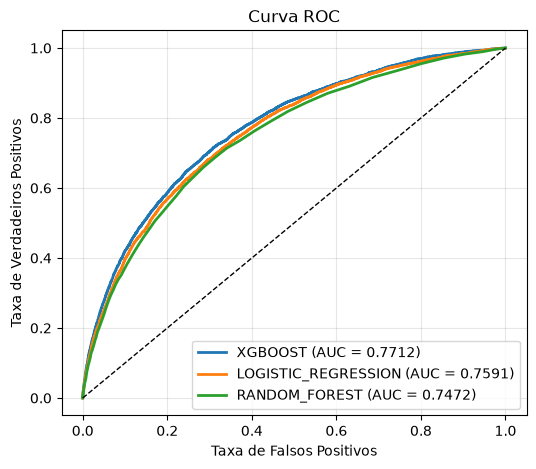

In [13]:
# --- CÉLULA 4: Comparação entre células método AUC/ROC--
# Busca dinâmica: procura qualquer arquivo que termine em _model.pkl
plt.figure(figsize=(6, 5))
for model_name in df_resumo ["Modelo"]:
    model,threshold = carregar_modelo(model_name)
    X_aligned = alinhar_features (model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})', lw=2)

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title(f'Curva ROC')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

AUC ROC Antes de utilizar a base de testes <br><br>
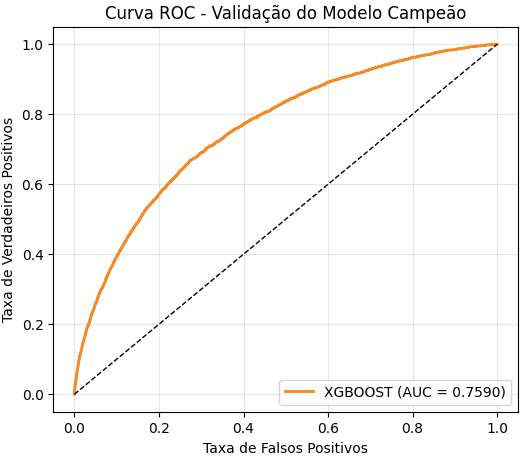

Carregando: xgboost_model.pkl
Carregando: logistic_regression_model.pkl
Carregando: random_forest_model.pkl


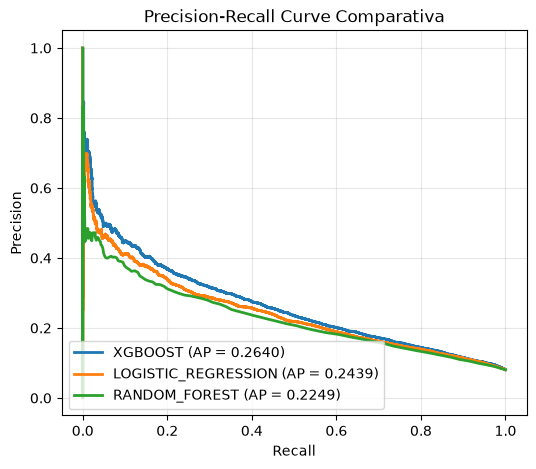

In [14]:
# --- CÉLULA 5: Precision-Recall Curve comparativa ---

plt.figure(figsize=(6, 5))
for model_name in df_resumo ["Modelo"]:
    model,threshold = carregar_modelo(model_name)
    X_aligned = alinhar_features (model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]

    # Precision x Recall
    precision, recall, threshold = precision_recall_curve(y_test, probs)
    ap_score = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f'{model_name} (AP = {ap_score:.4f})', lw=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve Comparativa')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()


Carregando: xgboost_model.pkl


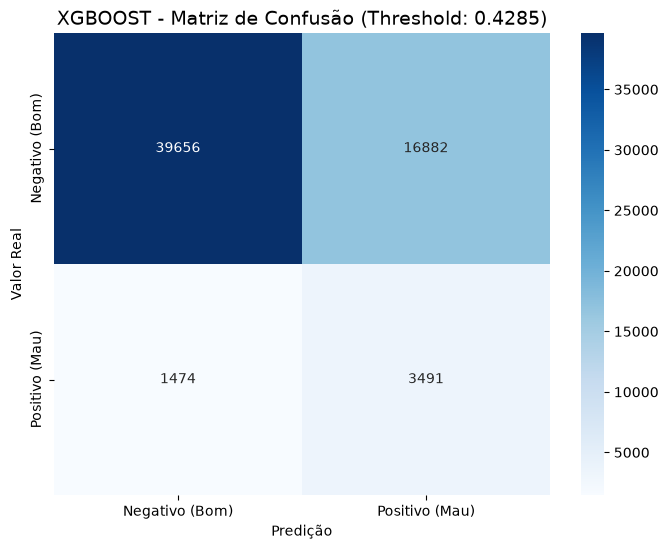

Carregando: logistic_regression_model.pkl


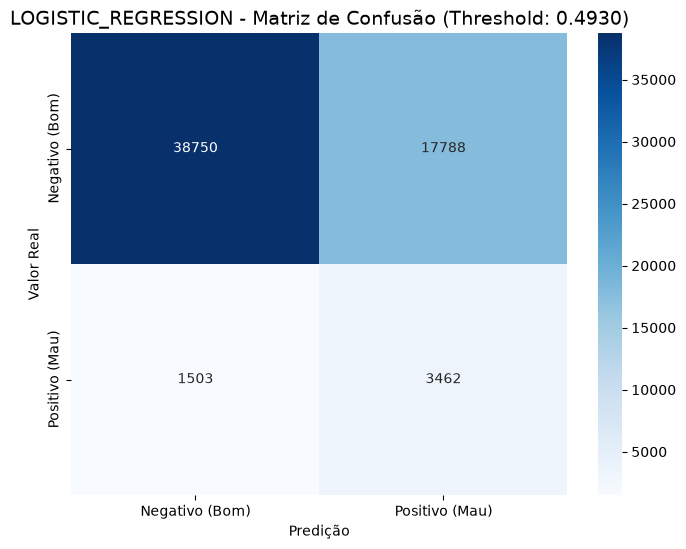

Carregando: random_forest_model.pkl


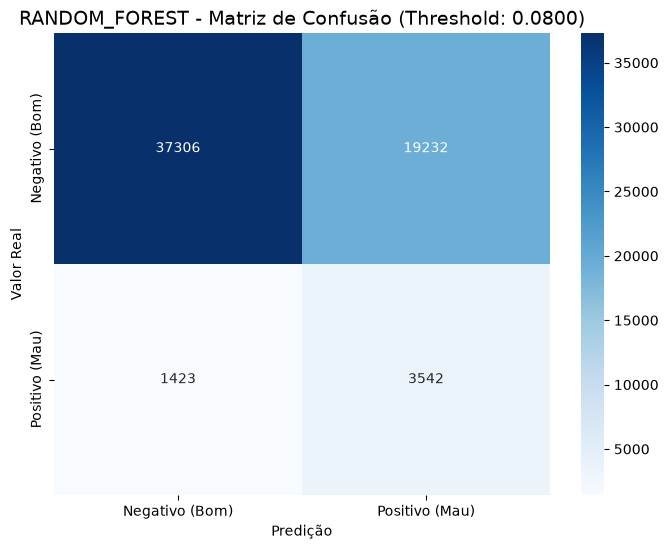

In [15]:
# --- CÉLULA 6: Matriz de Confusão ---

for model_name in df_resumo ["Modelo"]:
    model,threshold = carregar_modelo(model_name)
    X_aligned = alinhar_features (model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    # plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negativo (Bom)', 'Positivo (Mau)'], 
                yticklabels=['Negativo (Bom)', 'Positivo (Mau)'])

    plt.title(f'{model_name} - Matriz de Confusão (Threshold: {threshold:.4f})', fontsize=14)
    plt.xlabel('Predição')
    plt.ylabel('Valor Real')
    plt.show()

In [16]:
# --- CÉLULA 7: Investigação de Viés por Fontes Externas ---
# Vamos comparar o EXT_SOURCE_2 (que geralmente é muito forte) 
# entre os Falsos Positivos e o resto da base.

fp_indices = (y_test == 0) & (y_pred == 1)
df_fp = X_test[fp_indices]
df_outros = X_test[~fp_indices]

print("--- Comparação de Fontes Externas ---")
print(f"Média EXT_SOURCE_2 nos Falsos Positivos: {df_fp['EXT_SOURCE_2'].mean():.4f}")
print(f"Média EXT_SOURCE_2 no restante da base: {df_outros['EXT_SOURCE_2'].mean():.4f}")

# Dica: Se a média dos FP for muito baixa, o modelo está "viciado" 
# em reprovar quem tem score baixo nessas fontes, ignorando que o DTI é bom.

--- Comparação de Fontes Externas ---
Média EXT_SOURCE_2 nos Falsos Positivos: 0.4052
Média EXT_SOURCE_2 no restante da base: 0.5647


Carregando: xgboost_model.pkl


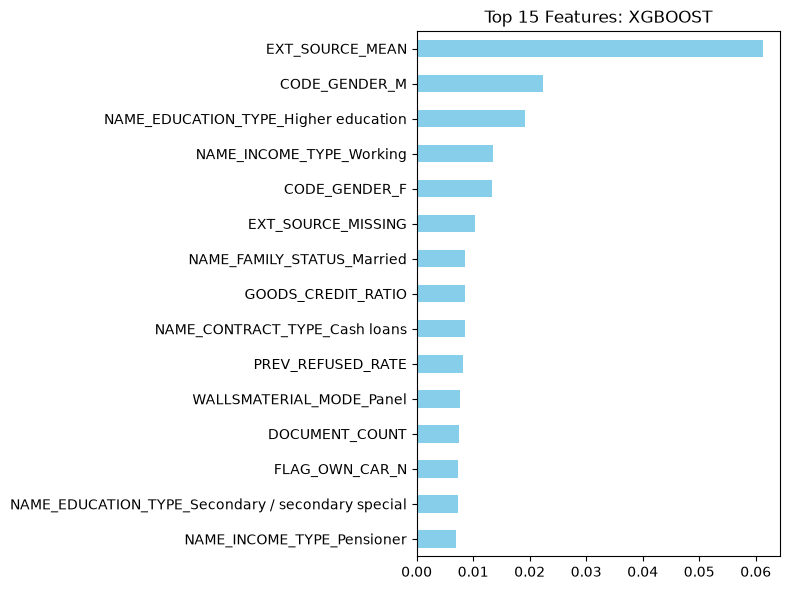

Carregando: logistic_regression_model.pkl


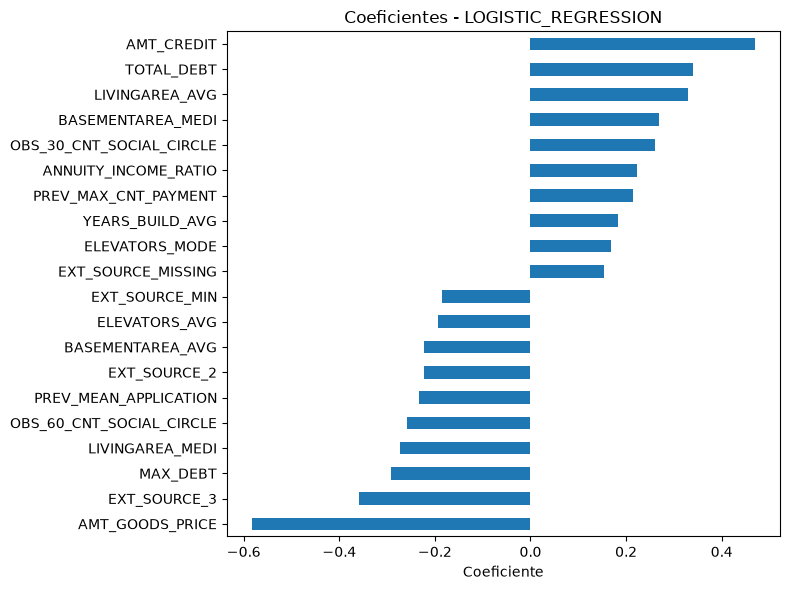

Carregando: random_forest_model.pkl


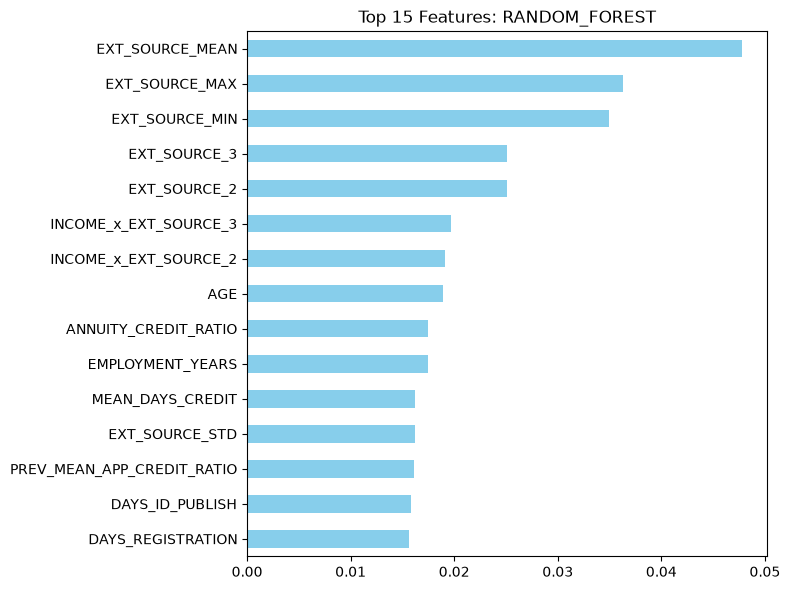

In [17]:
# --- CÉLULA 8: interpretabilidade específica ---

for model_name in df_resumo ["Modelo"]:
    model,threshold = carregar_modelo(model_name)
    est = model.named_steps['model'] if isinstance(model, Pipeline) else model
    if model_name in ["XGBOOST","RANDOM_FOREST"]:
        if hasattr(est, 'feature_importances_'):
            imp = pd.Series(est.feature_importances_, index=feature_names).nlargest(15)
            plt.figure(figsize=(8, 6))
            imp.sort_values().plot(kind='barh', color='skyblue')
            plt.title(f'Top 15 Features: {model_name}')
            plt.tight_layout()
            plt.show()
            plt.close()

    else:       
        if hasattr(est, 'coef_'):
            coef = pd.Series(est.coef_[0], index=feature_names)

            top_positivos = coef.nlargest(10)
            top_negativos = coef.nsmallest(10)

            coef_plot = pd.concat([top_negativos, top_positivos])

            plt.figure(figsize=(8, 6))
            coef_plot.sort_values().plot(kind="barh")
            plt.title(f"Coeficientes - {model_name}")
            plt.xlabel("Coeficiente")
            plt.tight_layout()
            plt.show()
            plt.close()


In [18]:
# --- CÉLULA 9: Conclusão ---
display(df_resumo)
best_model = df_resumo.iloc[0]
# Extrair principais métricas
nome_modelo = best_model["Modelo"]
roc_auc = best_model["ROC AUC"]
acuracia = best_model["Acurácia"]
precisao = best_model["Precisão"]
recall = best_model["Recall"]
f1 = best_model["F1"]
threshold = best_model["Threshold"]
#Exibir resumo do modelo campeão
print("=== Modelo Campeão ===")
print(f"Modelo: {best_model}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Threshold: {threshold:.4f}")
#Texto final interpretativo
print("\n=== Conclusão ===")
print(
    f"O modelo com melhor desempenho geral foi o {best_model}, "
    f"apresentando ROC AUC de {roc_auc:.4f}. "
    "A escolha considera principalmente a capacidade de separação entre bons e maus pagadores, "
    "além do equilíbrio observado entre precisão, recall e F1-score."
)

,Modelo,ROC AUC,Acurácia,Precisão,Recall,F1,Threshold
2,XGBOOST,0.771163,0.701543,0.171354,0.703122,0.275555,0.428484
0,LOGISTIC_REGRESSION,0.759125,0.686341,0.162918,0.697281,0.264124,0.492990
1,RANDOM_FOREST,0.747248,0.664163,0.155528,0.713394,0.255381,0.080000


=== Modelo Campeão ===
Modelo: Modelo        XGBOOST
ROC AUC      0.771163
Acurácia     0.701543
Precisão     0.171354
Recall       0.703122
F1           0.275555
Threshold    0.428484
Name: 2, dtype: object
ROC AUC: 0.7712
Acurácia: 0.7015
Precisão: 0.1714
Recall: 0.7031
F1-score: 0.2756
Threshold: 0.4285

=== Conclusão ===
O modelo com melhor desempenho geral foi o Modelo        XGBOOST
ROC AUC      0.771163
Acurácia     0.701543
Precisão     0.171354
Recall       0.703122
F1           0.275555
Threshold    0.428484
Name: 2, dtype: object, apresentando ROC AUC de 0.7712. A escolha considera principalmente a capacidade de separação entre bons e maus pagadores, além do equilíbrio observado entre precisão, recall e F1-score.
